Raw Dataset Preprocessing (Cleaning) for Surrogate Modelling

This script processes the raw Monte Carlo dataset generated by OpenMC before machine learning training. It acts as the 
bridge between the stochastic ground-truth simulations and the ML surrogate models.

Methodology:
Section 1:
- loads the raw Latin Hypercube Sampled (LHS) dataset
- Drops failed OpenMC simulations (missing k_eff)
- Extracts and outputs total and average computational times
Section 2:
- Drops non-physical parameters
- Drops Moderator Density due to its collinearity with Moderator Temperature
- Saves the final cleaned dataset for ML training
- Outputs a dataset summary for verification of results

Section 3 (Using 'Claude.ai'):
- creates plots for k_eff distribution and monte carlo uncertainty (to verify the ground-truth datset)
- Uses matplotlib to create a spearman correalation heatmap
    
Additional Files:
- raw_dataset.csv (raw Monte Carlo output input)
- dataset_cleaned.csv (processed feature matrix output)
- ground_truth_plots.png (k_eff distribution and monte carlo uncertainty plots)
- spearman_heatmap.png (Spearman correalation heatmap plot)

Author: Joseph Dehghani - 201725400
Course: Individual Project, Civil Engineering, The University of Liverpool
Date: 31/03/2026

References:
- Tao, Q., et al. (2025). Machine learning strategies for small sample size in materials science. available at: 
    https://link.springer.com/article/10.1007/s40843-024-3204-5 (Accessed: 31 March 2026).
- Alizadeh, R., et al. (2020). Managing computational complexity using surrogate models: a critical 
    review. available at: https://link.springer.com/article/10.1007/s00163-020-00336-7 (Accessed: 31 March 2026).
- Breiman, L. (2001) 'Random Forests', Machine Learning, 45(1), pp. 5-32. Available at: 
      https://doi.org/10.1023/A:1010933404324 (Accessed: 31 March 2026).

In [1]:
# ------- Section 1 --------

# Required Imports
import pandas as pd # To load and alter INPUT_CSV
from pathlib import Path 

# Configure file paths
INPUT_CSV = Path('raw_dataset.csv') # raw dataset input path
OUTPUT_CSV = Path('dataset_cleaned.csv') # cleaned dataset output path

# Load the raw dataset
ds = pd.read_csv(INPUT_CSV)
print(f"Loaded {len(ds)} samples")

# Remove failed runs (missing keff)
num_rows = len(ds)
ds = ds.dropna(subset=['K_eff'])
print(f"{len(ds)} / {num_rows} valid runs")

# Calculate and output compute times
total_time = ds['Compute_Time_sec'].sum()
avg_time = ds['Compute_Time_sec'].mean()
print(f"Total Compute Time:   {total_time:.2f} seconds")
print(f"Average Compute Time: {avg_time:.2f} seconds per run")

Loaded 1000 samples
1000 / 1000 valid runs
Total Compute Time:   60468.14 seconds
Average Compute Time: 60.47 seconds per run


In [2]:
# ------- Section 2 --------

# Drop non-features
# standard_deviation: OpenMC parameter not a physical input
# Compute_Time_sec: simulation data not a physical input  
# Moderator_Density_gcc: collinear with Moderator_Temperature_K so will hav no effect on model accuracy
# confirmed by Spearman heatmap before dropping
drop_columns = ['standard_deviation', 'Compute_Time_sec', 'Moderator_Density_gcc']
ds_cleaned = ds.drop(columns=drop_columns)

# Export cleaned dataset to output csv
ds_cleaned.to_csv(OUTPUT_CSV, index=False)
print(f"\nSaved {len(ds_cleaned)} samples to {OUTPUT_CSV}")

# Quick summary statistics on cleaned dataset
print("\nDataset summary:")
print(ds_cleaned.describe().round(4))


Saved 1000 samples to dataset_cleaned.csv

Dataset summary:
       Fuel_Temperature_K  Cladding_Temperature_K  Moderator_Temperature_K  \
count           1000.0000               1000.0000                1000.0000   
mean             849.9941                599.9987                 550.0014   
std              202.1753                 57.7620                  28.8814   
min              500.5034                500.1763                 500.0020   
25%              675.4590                550.0014                 525.0122   
50%              849.9915                599.9852                 549.9970   
75%             1024.9133                649.9925                 574.9430   
max             1199.6102                699.8308                 599.9547   

       Boron_ppm    CR_Step      K_eff  
count  1000.0000  1000.0000  1000.0000  
mean    617.5061   123.9920     1.0300  
std     356.6888    71.6312     0.0714  
min       0.7757     0.0000     0.8596  
25%     308.9787    62.0000    

Saved 'ground_truth_plots.png'


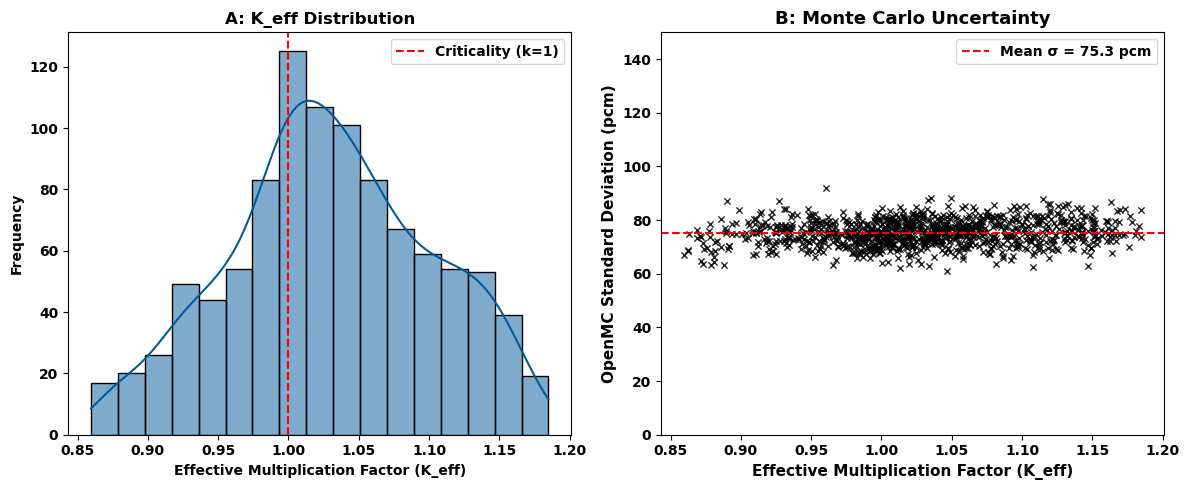

Saved 'Spearman_Correlation_Matrix.png'


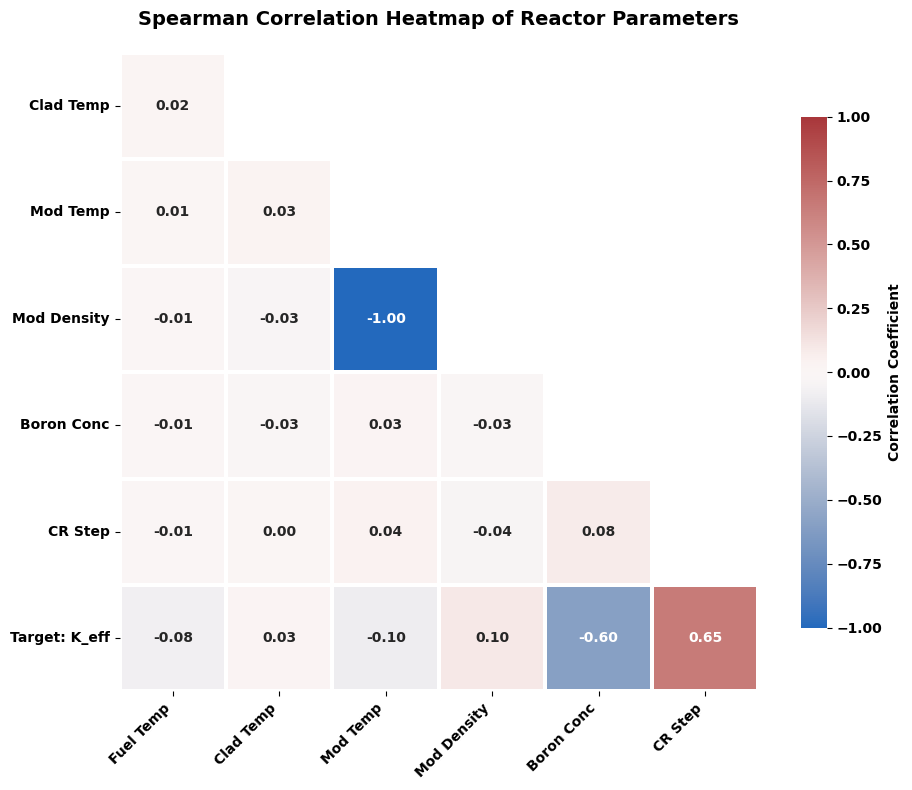

In [4]:
# ------- Section 3 --------
# created using 'Claude.ai'

# Required Imports
import pandas as pd # to read the output dataset
import seaborn as sns # for statistical plotting
import matplotlib.pyplot as plt # for plots and exporting
import numpy as np # for dealing with matrices
import os # to create output folder

# Load the dataset
df = pd.read_csv('raw_dataset.csv') 

# Remove failed runs (missing keff)
initial_rows = len(df)
df = df.dropna(subset=['K_eff'])

# Globally set font styles
plt.rcParams.update({
    'font.weight': 'bold',
    'axes.labelweight': 'bold',
    'axes.titleweight': 'bold',
    'figure.titleweight': 'bold'
})

# create output folder if it doesn't exist
os.makedirs('Cleaned Dataset Plots', exist_ok=True)

# ---------- K_eff distribution and Monte Carlo Uncertainty Plots ---------- #

# Set up 2 sided plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5), facecolor='white')

# Panel A: K_eff Distribution
sns.histplot(df['K_eff'], kde=True, ax=axes[0], color='#005A9C')
axes[0].axvline(1.0, color='red', linestyle='--', linewidth=1.5, label='Criticality (k=1)')
axes[0].set_title('A: K_eff Distribution')
axes[0].set_xlabel('Effective Multiplication Factor (K_eff)')
axes[0].set_ylabel('Frequency')
axes[0].legend(prop={'weight': 'bold'})

# Panel B: Monte Carlo Uncertainty 
std_pcm = df['standard_deviation'] * 100000 # Multiply by 100,000 to convert raw standard deviation to pcm
mean_std_pcm = std_pcm.mean() # calculate the mean for display
axes[1].scatter(df['K_eff'], std_pcm, color='black', marker='x', alpha=0.85, linewidth=1.0, s=20)
axes[1].axhline(mean_std_pcm, color='red', linestyle='--', linewidth=1.5, label=f'Mean σ = {mean_std_pcm:.1f} pcm')
axes[1].set_title('B: Monte Carlo Uncertainty', fontsize=13)
axes[1].set_xlabel('Effective Multiplication Factor (K_eff)', fontsize=11)
axes[1].set_ylabel('OpenMC Standard Deviation (pcm)', fontsize=11)
axes[1].legend(prop={'weight': 'bold'})
axes[1].set_ylim(0, 150)

plt.tight_layout()
plt.savefig('Cleaned Dataset Plots/ground_truth_plots.png', dpi=300, bbox_inches='tight')
print("Saved 'ground_truth_plots.png'")
plt.show() # display plot 1 

# ---------- Spearman Correlation Heatmap ---------- #

# Clean non-physical values for the correlation matrix
drop_columns = ['standard_deviation', 'Compute_Time_sec']
df_cleaned = df.drop(columns=drop_columns)

# Rename columns to clean labels
clean_labels = {
    'Fuel_Temperature_K': 'Fuel Temp',
    'Cladding_Temperature_K': 'Clad Temp',
    'Moderator_Temperature_K': 'Mod Temp',
    'Moderator_Density_gcc': 'Mod Density', 
    'Boron_ppm': 'Boron Conc',
    'CR_Step': 'CR Step',
    'K_eff': 'Target: K_eff'
}
df_plot = df_cleaned.rename(columns=clean_labels)

# Calculate the spearman correlation matrix
corr = df_plot.corr(method='spearman')

# Create the mask on the FULL matrix 
mask = np.triu(np.ones_like(corr, dtype=bool))

# Slice BOTH the correlation matrix and the mask
corr_sliced = corr.iloc[1:, :-1]
mask_sliced = mask[1:, :-1]

# Set up the matplotlib figure
plt.figure(figsize=(10, 8), facecolor='white')

# Draw the heatmap with the sliced data and sliced mask
sns.heatmap(corr_sliced, 
            mask=mask_sliced, 
            cmap='vlag', 
            vmin=-1.0, 
            vmax=1.0, 
            center=0,
            square=True, 
            linewidths=1.5, 
            cbar_kws={"shrink": .8, "label": "Correlation Coefficient"},
            annot=True, 
            fmt=".2f", 
            annot_kws={"size": 10, "weight": "bold"})

# Formatting tweaks
plt.title("Spearman Correlation Heatmap of Reactor Parameters", fontsize=14, pad=20)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)

# Export plot
plt.tight_layout()
plt.savefig('Cleaned Dataset Plots/Spearman_Correlation_Matrix.png', dpi=300, bbox_inches='tight')
print("Saved 'Spearman_Correlation_Matrix.png'")
plt.show()